In [7]:
# Import essential models and functions from sklearn
from sklearn.linear_model import LinearRegression, LogisticRegression 
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, StratifiedKFold
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
sb.set()
np.random.seed(42)

In [15]:
d  = pd.read_csv('clean_data.csv')
d1 = pd.read_csv('owid-energy-data.csv')

candidate_features = [
    "population", "electricity_generation", "primary_energy_consumption",
    "fossil_share_energy", "energy_per_capita",
    "renewables_share_energy", "coal_share_energy", "oil_share_energy",
    "gas_share_energy", "low_carbon_share_energy", "renewables_share_elec"
]

years = sorted(d1["year"].unique())
year_top_corr = {}

for yr in years:
    year_slice = d1[d1["year"] == yr]
    avail_cols = [c for c in candidate_features if c in year_slice.columns]
    corr_df = year_slice[avail_cols + ["gdp"]].dropna()
    if corr_df.shape[0] == 0:
        year_top_corr[yr] = pd.Series(dtype=float)
        continue
    corr = corr_df.corr(numeric_only=True)["gdp"].drop("gdp")
    corr = corr.dropna().sort_values(key=lambda x: x.abs(), ascending=False)
    year_top_corr[yr] = corr

N_TOP = 8
rows = []
for yr, corr in year_top_corr.items():
    topN = corr.head(N_TOP)
    row = {"year": yr}
    for i in range(N_TOP):
        if i < len(topN):
            row[f"feature_{i+1}"] = topN.index[i]
            row[f"corr_{i+1}"] = round(topN.iloc[i], 4)
        else:
            row[f"feature_{i+1}"] = None
            row[f"corr_{i+1}"] = None
    rows.append(row)

year_top8_df = pd.DataFrame(rows).sort_values("year").reset_index(drop=True)
print(year_top8_df)

     year                   feature_1  corr_1                   feature_2  \
0    1900                        None     NaN                        None   
1    1901                        None     NaN                        None   
2    1902                        None     NaN                        None   
3    1903                        None     NaN                        None   
4    1904                        None     NaN                        None   
5    1905                        None     NaN                        None   
6    1906                        None     NaN                        None   
7    1907                        None     NaN                        None   
8    1908                        None     NaN                        None   
9    1909                        None     NaN                        None   
10   1910                        None     NaN                        None   
11   1911                        None     NaN                        None   

In [16]:
#G7 

g7_countries = ["United States", "Canada", "United Kingdom", "France", "Germany", "Italy", "Japan"]

d1 = d1.sort_values(["country", "year"])
d1["gdp_growth"] = d1.groupby("country")["gdp"].pct_change(fill_method=None)
d1["growth_median_year"] = d1.groupby("year")["gdp_growth"].transform("median")
d1["growth_label"] = np.where(d1["gdp_growth"] > d1["growth_median_year"], 1, 0)
d1.loc[d1["gdp_growth"].isna(), "growth_label"] = np.nan

g7_df = d1[d1["country"].isin(g7_countries)].copy()

g7_corr_by_country = {}
for country in g7_countries:
    sub = g7_df[g7_df["country"] == country]
    valid = sub[candidate_features + ["gdp"]].dropna()
    if valid.shape[0] < 5:
        continue
    corr = valid.corr(numeric_only=True)["gdp"].drop("gdp").dropna()
    g7_corr_by_country[country] = corr.sort_values(key=lambda x: x.abs(), ascending=False)

for country, corr in g7_corr_by_country.items():
    print(f"\n--- {country} ---")
    print(corr.head(5))


#different countries - different top1 predictors


--- United States ---
population                 0.992664
electricity_generation     0.907407
fossil_share_energy       -0.903147
low_carbon_share_energy    0.903147
renewables_share_energy    0.789531
Name: gdp, dtype: float64

--- Canada ---
population                    0.988568
electricity_generation        0.955950
primary_energy_consumption    0.948217
gas_share_energy              0.921617
coal_share_energy            -0.880050
Name: gdp, dtype: float64

--- United Kingdom ---
population                 0.944652
coal_share_energy         -0.906359
renewables_share_energy    0.777929
renewables_share_elec      0.773241
energy_per_capita         -0.764373
Name: gdp, dtype: float64

--- France ---
population                 0.985066
oil_share_energy          -0.951440
gas_share_energy           0.939689
coal_share_energy         -0.912479
low_carbon_share_energy    0.893578
Name: gdp, dtype: float64

--- Germany ---
low_carbon_share_energy    0.972763
fossil_share_energy       -0.

In [51]:
# VIF & labels of strong/weak electroenergies

g7_df["elec_median_year"] = g7_df.groupby("year")["electricity_generation"].transform("median")
g7_df["power_label"] = np.where(g7_df["electricity_generation"] > g7_df["elec_median_year"], 1, 0)

model_features = ["electricity_generation"]
req_cols = model_features + ["growth_label", "power_label"]
g7_model_df = g7_df.dropna(subset=req_cols).copy()

X = g7_model_df[model_features].copy()
y_growth = g7_model_df["growth_label"].astype(int)
y_power  = g7_model_df["power_label"].astype(int)
y_gdp    = g7_model_df["gdp"].copy()

X_vif = add_constant(X)
vif_data = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
print(vif_data[vif_data["feature"] != "const"].sort_values("VIF", ascending=False))

                  feature        VIF
1  electricity_generation  17.680591
2              population  17.680591


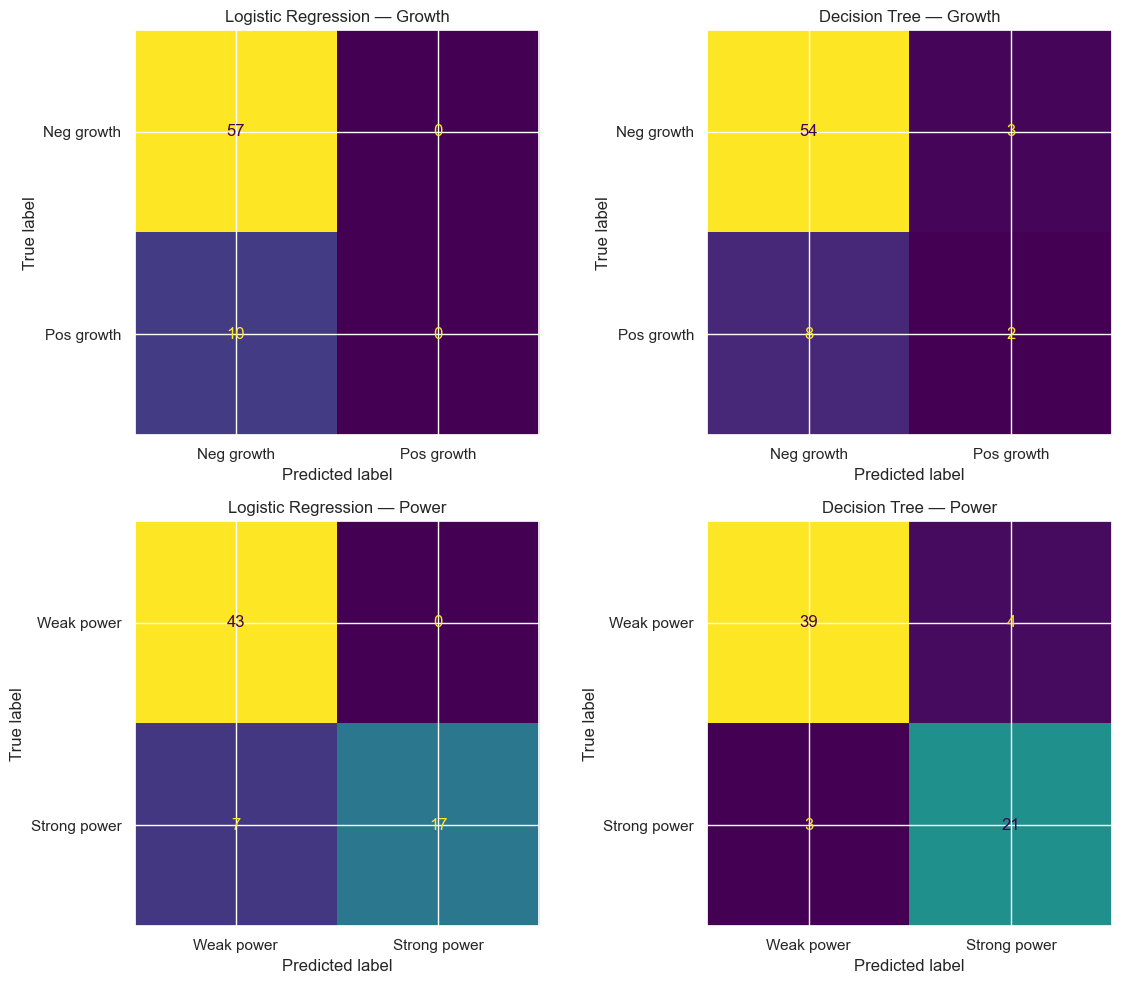

In [48]:
g7_countries = ["United States", "Canada", "United Kingdom", "France", "Germany", "Italy", "Japan"]

d1 = pd.read_csv('owid-energy-data.csv')
d1 = d1.sort_values(["country", "year"])
d1["gdp_growth"] = d1.groupby("country")["gdp"].pct_change(fill_method=None)
d1["growth_median_year"] = d1.groupby("year")["gdp_growth"].transform("median")
d1["growth_label"] = np.where(d1["gdp_growth"] > d1["growth_median_year"], 1, 0)
d1.loc[d1["gdp_growth"].isna(), "growth_label"] = np.nan

g7_df = d1[d1["country"].isin(g7_countries)].copy()
g7_df["elec_median_year"] = g7_df.groupby("year")["electricity_generation"].transform("median")
g7_df["power_label"] = np.where(g7_df["electricity_generation"] > g7_df["elec_median_year"], 1, 0)

model_features = ["electricity_generation"]
req_cols = model_features + ["growth_label", "power_label", "gdp"]
g7_model_df = g7_df.dropna(subset=req_cols).copy()

X = g7_model_df[model_features].copy()
y_growth = g7_model_df["growth_label"].astype(int)
y_power  = g7_model_df["power_label"].astype(int)
y_gdp    = g7_model_df["gdp"].copy()

X_train, X_test, ygr_train, ygr_test, ypw_train, ypw_test, ygdp_train, ygdp_test = train_test_split(
    X, y_growth, y_power, y_gdp, test_size=0.25, random_state=42, stratify=y_growth
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=model_features, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test), columns=model_features, index=X_test.index)

logreg_growth = LogisticRegression(max_iter=1000, random_state=42)
logreg_growth.fit(X_train_scaled, ygr_train)
pred_lg_growth = logreg_growth.predict(X_test_scaled)

logreg_power = LogisticRegression(max_iter=1000, random_state=42)
logreg_power.fit(X_train_scaled, ypw_train)
pred_lg_power = logreg_power.predict(X_test_scaled)

dt_growth = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_growth.fit(X_train, ygr_train)
pred_dt_growth = dt_growth.predict(X_test)

dt_power = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_power.fit(X_train, ypw_train)
pred_dt_power = dt_power.predict(X_test)

linreg = LinearRegression()
linreg.fit(X_train, ygdp_train)
test_r2 = linreg.score(X_test, ygdp_test)
test_mse = mean_squared_error(ygdp_test, linreg.predict(X_test))

# ---- Confusion matrices ----
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

cm_lg_growth = confusion_matrix(ygr_test, pred_lg_growth)
ConfusionMatrixDisplay(cm_lg_growth, display_labels=["Neg growth","Pos growth"]).plot(ax=axes[0,0], colorbar=False)
axes[0,0].set_title("Logistic Regression — Growth")

cm_dt_growth = confusion_matrix(ygr_test, pred_dt_growth)
ConfusionMatrixDisplay(cm_dt_growth, display_labels=["Neg growth","Pos growth"]).plot(ax=axes[0,1], colorbar=False)
axes[0,1].set_title("Decision Tree — Growth")

cm_lg_power = confusion_matrix(ypw_test, pred_lg_power)
ConfusionMatrixDisplay(cm_lg_power, display_labels=["Weak power","Strong power"]).plot(ax=axes[1,0], colorbar=False)
axes[1,0].set_title("Logistic Regression — Power")

cm_dt_power = confusion_matrix(ypw_test, pred_dt_power)
ConfusionMatrixDisplay(cm_dt_power, display_labels=["Weak power","Strong power"]).plot(ax=axes[1,1], colorbar=False)
axes[1,1].set_title("Decision Tree — Power")

plt.tight_layout()
plt.savefig("g7_confusion_matrices_all.png", dpi=150)
plt.show()

In [49]:
# Regression models and metrics
pred_gdp_test = linreg.predict(X_test)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(ygdp_test, pred_gdp_test, alpha=0.6, color="steelblue")
lims = [min(ygdp_test.min(), pred_gdp_test.min()), max(ygdp_test.max(), pred_gdp_test.max())]
axes[0].plot(lims, lims, 'r--', label="Perfect fit")
axes[0].set_xlabel("Actual GDP")
axes[0].set_ylabel("Predicted GDP")
axes[0].set_title(f"Linear Regression: Actual vs Predicted\nTest R2={test_r2:.3f}")
axes[0].legend()

residuals = ygdp_test - pred_gdp_test
axes[1].scatter(pred_gdp_test, residuals, alpha=0.6, color="darkorange")
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Predicted GDP")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residual Plot")

plt.tight_layout()
plt.savefig("g7_linreg_diagnostics.png", dpi=150)
plt.close()

In [50]:
all_results = [
    {"Model":"Logistic Regression","Target":"Growth","Accuracy":accuracy_score(ygr_test,pred_lg_growth),
     "Precision":precision_score(ygr_test,pred_lg_growth,zero_division=0),
     "Recall":recall_score(ygr_test,pred_lg_growth,zero_division=0),
     "F1":f1_score(ygr_test,pred_lg_growth,zero_division=0), "R2":None, "MSE":None},
    {"Model":"Decision Tree","Target":"Growth","Accuracy":accuracy_score(ygr_test,pred_dt_growth),
     "Precision":precision_score(ygr_test,pred_dt_growth,zero_division=0),
     "Recall":recall_score(ygr_test,pred_dt_growth,zero_division=0),
     "F1":f1_score(ygr_test,pred_dt_growth,zero_division=0), "R2":None, "MSE":None},
    {"Model":"Logistic Regression","Target":"Power","Accuracy":accuracy_score(ypw_test,pred_lg_power),
     "Precision":precision_score(ypw_test,pred_lg_power,zero_division=0),
     "Recall":recall_score(ypw_test,pred_lg_power,zero_division=0),
     "F1":f1_score(ypw_test,pred_lg_power,zero_division=0), "R2":None, "MSE":None},
    {"Model":"Decision Tree","Target":"Power","Accuracy":accuracy_score(ypw_test,pred_dt_power),
     "Precision":precision_score(ypw_test,pred_dt_power,zero_division=0),
     "Recall":recall_score(ypw_test,pred_dt_power,zero_division=0),
     "F1":f1_score(ypw_test,pred_dt_power,zero_division=0), "R2":None, "MSE":None},
    {"Model":"Linear Regression","Target":"GDP (regression)","Accuracy":None,"Precision":None,
     "Recall":None,"F1":None,"R2":test_r2,"MSE":test_mse},
]

full_results_df = pd.DataFrame(all_results).round(4)
full_results_df.to_csv("g7_all_models_metrics.csv", index=False)
print(full_results_df)

                 Model            Target  Accuracy  Precision  Recall      F1  \
0  Logistic Regression            Growth    0.8507       0.00  0.0000  0.0000   
1        Decision Tree            Growth    0.8358       0.40  0.2000  0.2667   
2  Logistic Regression             Power    0.8955       1.00  0.7083  0.8293   
3        Decision Tree             Power    0.8955       0.84  0.8750  0.8571   
4    Linear Regression  GDP (regression)       NaN        NaN     NaN     NaN   

       R2           MSE  
0     NaN           NaN  
1     NaN           NaN  
2     NaN           NaN  
3     NaN           NaN  
4  0.9418  1.245729e+24  


(25, 3) (6, 3)
Intercept of Regression 	: b =  174034939680.7365
Coefficients of Regression 	: a =  [-1.47790443e+04  1.70248789e+08  1.71596138e+10]

                   Predictors  Coefficients
0                  population -1.477904e+04
1  primary_energy_consumption  1.702488e+08
2      electricity_generation  1.715961e+10



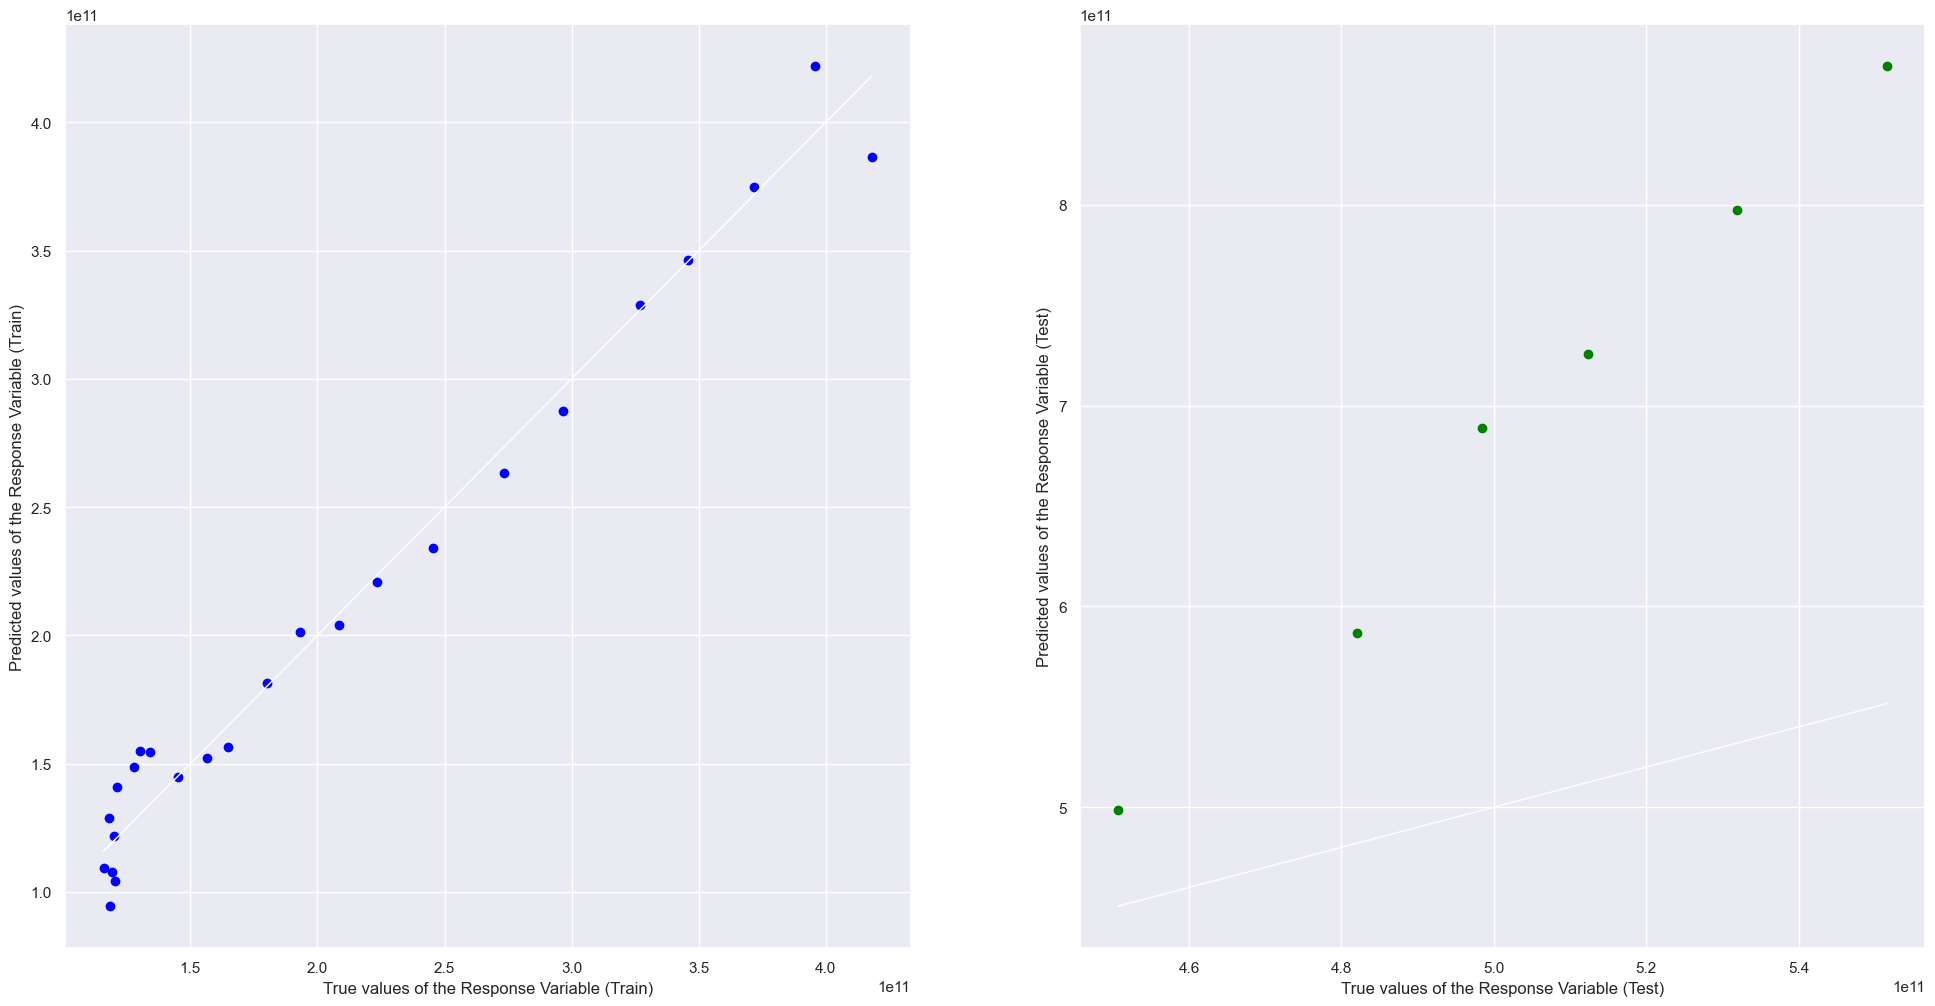

Goodness of Fit of Model 	Train Dataset
Explained Variance (R^2) 	: 0.9780969163993145
Mean Squared Error (MSE) 	: 2.0678511714702387e+20

Goodness of Fit of Model 	Test Dataset
Explained Variance (R^2) 	: -40.22252080014991
Mean Squared Error (MSE) 	: 4.435866187213171e+22



In [12]:
# 3 Predictors


Algeria = pd.DataFrame(d1[d1["country"] == "Algeria"])

# Just the column names now — plain lists, not DataFrames
feature_cols = ["population","primary_energy_consumption","electricity_generation"]
target_col = "gdp"

train_df = Algeria[Algeria["year"] < 2010]
test_df  = Algeria[(Algeria["year"] >= 2010) & (Algeria["year"] <= 2015)]

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test  = test_df[feature_cols]
y_test  = test_df[target_col]

print(X_train.shape, X_test.shape)

# Linear Regression using Train Data
linreg = LinearRegression()         # create the linear regression object
linreg.fit(X_train, y_train)        # train the linear regression model

# Coefficients of the Linear Regression line
print('Intercept of Regression \t: b = ', linreg.intercept_)
print('Coefficients of Regression \t: a = ', linreg.coef_)
print()

# Print the Coefficients against Predictors
print(pd.DataFrame(list(zip(X_train.columns, linreg.coef_)), columns = ["Predictors", "Coefficients"]))
print()

# Predict Response corresponding to Predictors
y_train_pred = linreg.predict(X_train)
y_test_pred = linreg.predict(X_test)

# Plot the Predictions vs the True values
f, axes = plt.subplots(1, 2, figsize=(24, 12))
axes[0].scatter(y_train, y_train_pred, color = "blue")
axes[0].plot(y_train, y_train, 'w-', linewidth = 1)
axes[0].set_xlabel("True values of the Response Variable (Train)")
axes[0].set_ylabel("Predicted values of the Response Variable (Train)")
axes[1].scatter(y_test, y_test_pred, color = "green")
axes[1].plot(y_test, y_test, 'w-', linewidth = 1)
axes[1].set_xlabel("True values of the Response Variable (Test)")
axes[1].set_ylabel("Predicted values of the Response Variable (Test)")
plt.show()

# Check the Goodness of Fit (on Train Data)
print("Goodness of Fit of Model \tTrain Dataset")
print("Explained Variance (R^2) \t:", linreg.score(X_train, y_train))
print("Mean Squared Error (MSE) \t:", mean_squared_error(y_train, y_train_pred))
print()

# Check the Goodness of Fit (on Test Data)
print("Goodness of Fit of Model \tTest Dataset")
print("Explained Variance (R^2) \t:", linreg.score(X_test, y_test))
print("Mean Squared Error (MSE) \t:", mean_squared_error(y_test, y_test_pred))
print()

(38, 15)
(25, 2) (6, 2)
Intercept of Regression 	: b =  -519294569210.37067
Coefficients of Regression 	: a =  [1.15266883e+04 1.19754815e+09]

                   Predictors  Coefficients
0                  population  1.152669e+04
1  primary_energy_consumption  1.197548e+09



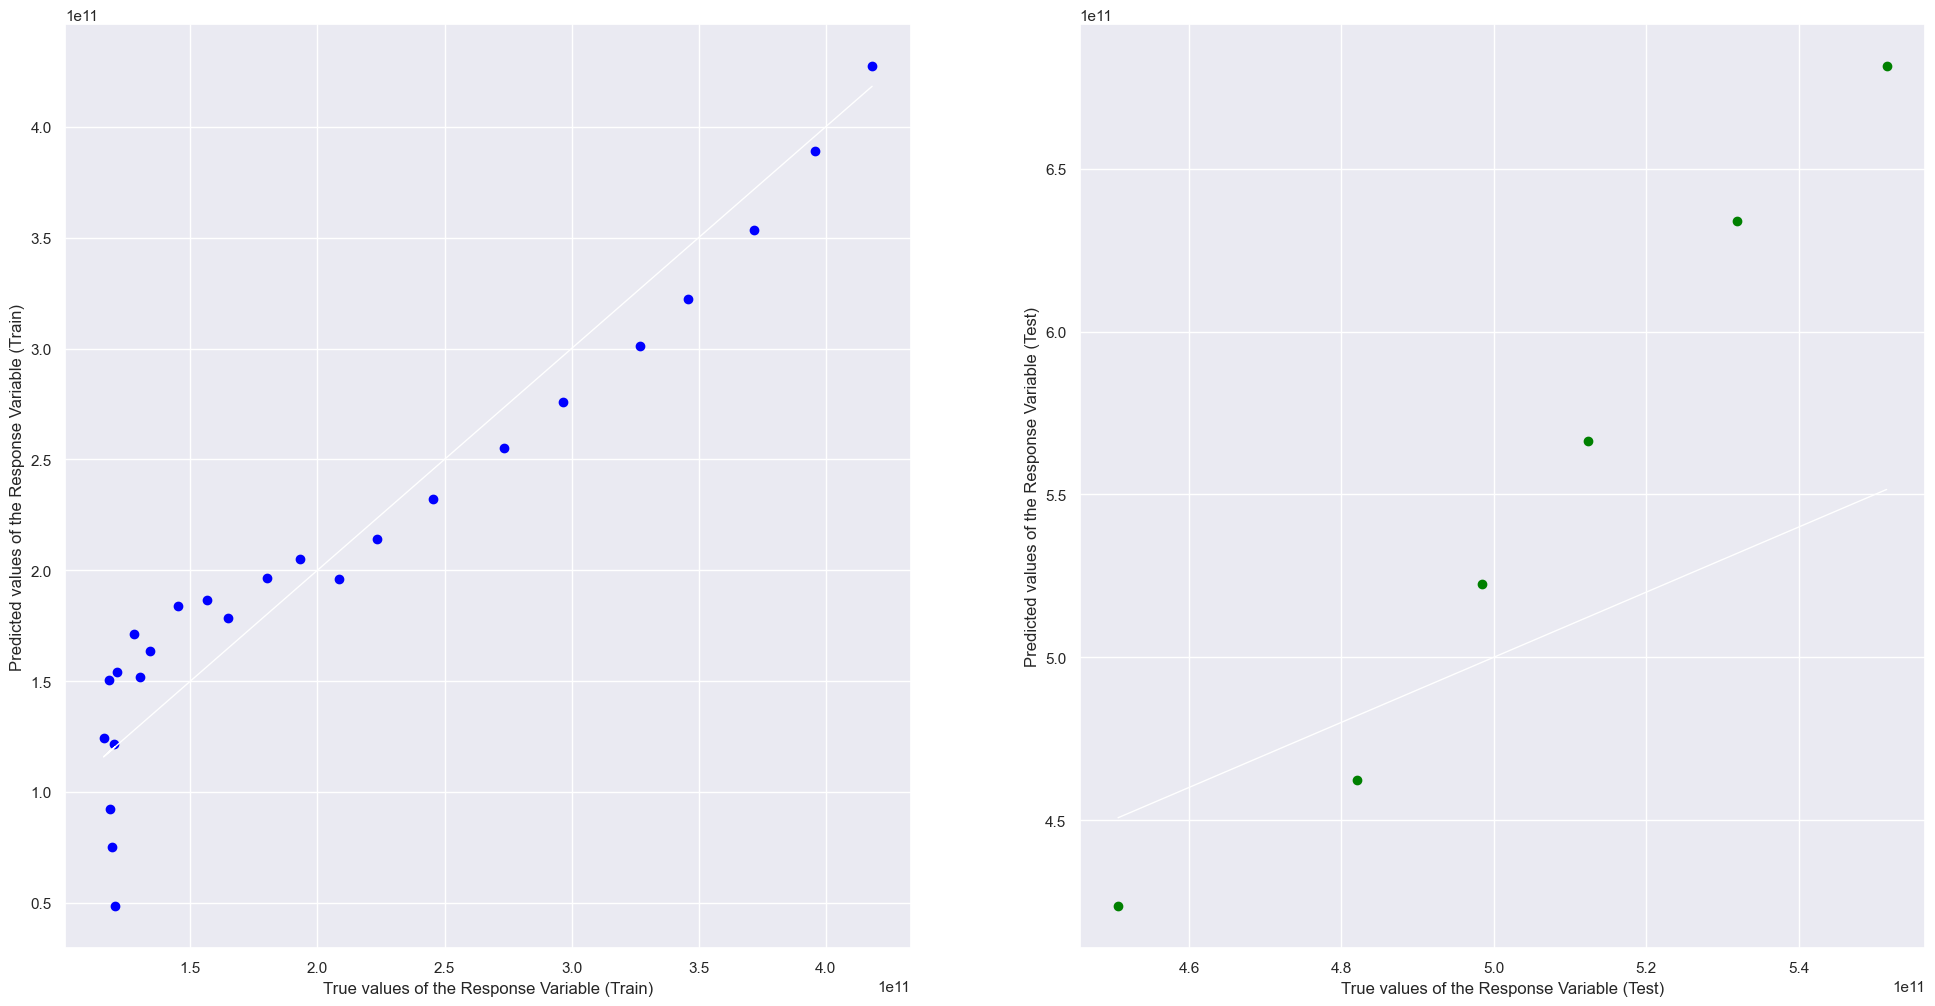

Goodness of Fit of Model 	Train Dataset
Explained Variance (R^2) 	: 0.9192618314684029
Mean Squared Error (MSE) 	: 7.622420633741264e+20

Goodness of Fit of Model 	Test Dataset
Explained Variance (R^2) 	: -3.9498670151867064
Mean Squared Error (MSE) 	: 5.326444695198904e+21


In [12]:
# 11 Predictors


# Import essential models and functions from sklearn
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
sb.set()

# ---- Step 1: Build a clean Algeria subset from the full dataset ----
all_candidate_cols = [
    "country", "year", "iso_code", "gdp",
    "population", "electricity_generation", "primary_energy_consumption", 
    "fossil_share_energy", "energy_per_capita",
    "renewables_share_energy", "coal_share_energy", "oil_share_energy", "gas_share_energy",
    "low_carbon_share_energy", "renewables_share_elec"
]

Algeria = d[d["country"] == "Algeria"][all_candidate_cols]
Algeria = Algeria.dropna()   # safe here since we already confirmed full coverage for these columns

print(Algeria.shape)   # sanity check -- expect around 31 rows

# ---- Step 2: Choose your final feature columns (based on your correlation analysis) ----
feature_cols = ["population", "primary_energy_consumption"]   # <-- edit this list as needed
target_col = "gdp"

# ---- Step 3: Temporal train/test split ----
train_df = Algeria[Algeria["year"] < 2010]
test_df  = Algeria[(Algeria["year"] >= 2010) & (Algeria["year"] <= 2015)]

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test  = test_df[feature_cols]
y_test  = test_df[target_col]

print(X_train.shape, X_test.shape)

# ---- Step 4: Fit Linear Regression ----
linreg = LinearRegression()
linreg.fit(X_train, y_train)

print('Intercept of Regression \t: b = ', linreg.intercept_)
print('Coefficients of Regression \t: a = ', linreg.coef_)
print()
print(pd.DataFrame(list(zip(X_train.columns, linreg.coef_)), columns=["Predictors", "Coefficients"]))
print()

# ---- Step 5: Predict ----
y_train_pred = linreg.predict(X_train)
y_test_pred  = linreg.predict(X_test)

# ---- Step 6: Plot predictions vs true values ----
f, axes = plt.subplots(1, 2, figsize=(24, 12))
axes[0].scatter(y_train, y_train_pred, color="blue")
axes[0].plot(y_train, y_train, 'w-', linewidth=1)
axes[0].set_xlabel("True values of the Response Variable (Train)")
axes[0].set_ylabel("Predicted values of the Response Variable (Train)")

axes[1].scatter(y_test, y_test_pred, color="green")
axes[1].plot(y_test, y_test, 'w-', linewidth=1)
axes[1].set_xlabel("True values of the Response Variable (Test)")
axes[1].set_ylabel("Predicted values of the Response Variable (Test)")
plt.show()

# ---- Step 7: Goodness of fit ----
print("Goodness of Fit of Model \tTrain Dataset")
print("Explained Variance (R^2) \t:", linreg.score(X_train, y_train))
print("Mean Squared Error (MSE) \t:", mean_squared_error(y_train, y_train_pred))
print()
print("Goodness of Fit of Model \tTest Dataset")
print("Explained Variance (R^2) \t:", linreg.score(X_test, y_test))
print("Mean Squared Error (MSE) \t:", mean_squared_error(y_test, y_test_pred))